In [98]:
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("mental_health_data final data.csv")
print(df.shape)
print(df.columns)

(50000, 17)
Index(['User_ID', 'Age', 'Gender', 'Occupation', 'Country',
       'Mental_Health_Condition', 'Severity', 'Consultation_History',
       'Stress_Level', 'Sleep_Hours', 'Work_Hours', 'Physical_Activity_Hours',
       'Social_Media_Usage', 'Diet_Quality', 'Smoking_Habit',
       'Alcohol_Consumption', 'Medication_Usage'],
      dtype='object')


In [99]:
df

,User_ID,Age,Gender,Occupation,Country,Mental_Health_Condition,Severity,Consultation_History,Stress_Level,Sleep_Hours,Work_Hours,Physical_Activity_Hours,Social_Media_Usage,Diet_Quality,Smoking_Habit,Alcohol_Consumption,Medication_Usage
0,1,36,Male,Education,Australia,Yes,NaN,Yes,Low,7.6,46,8,2.2,Healthy,Regular Smoker,Regular Drinker,Yes
1,2,48,Male,Engineering,Other,No,Low,No,Low,6.8,74,2,3.4,Unhealthy,Heavy Smoker,Social Drinker,No
2,3,18,Prefer not to say,Sales,India,No,NaN,Yes,Medium,7.1,77,9,5.9,Healthy,Heavy Smoker,Social Drinker,No
3,4,30,Non-binary,Engineering,Australia,No,Medium,No,Low,6.9,57,4,5.4,Average,Regular Smoker,Regular Drinker,No
4,5,58,Male,IT,USA,Yes,NaN,Yes,High,4.7,45,10,3.3,Unhealthy,Regular Smoker,Non-Drinker,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49996,44,Prefer not to say,Education,Australia,No,Medium,Yes,High,8.4,45,4,1.3,Unhealthy,Regular Smoker,Regular Drinker,Yes
49996,49997,19,Female,Other,Germany,No,NaN,Yes,High,9.9,68,6,5.1,Healthy,Occasional Smoker,Social Drinker,Yes
49997,49998,31,Prefer not to say,Education,India,Yes,Low,No,Medium,5.2,61,6,2.1,Average,Non-Smoker,Heavy Drinker,No
49998,49999,26,Prefer not to say,Other,UK,Yes,Low,No,High,8.2,59,0,1.9,Healthy,Occasional Smoker,Regular Drinker,Yes


In [100]:
df.dtypes

User_ID                      int64
Age                          int64
Gender                      object
Occupation                  object
Country                     object
Mental_Health_Condition     object
Severity                    object
Consultation_History        object
Stress_Level                object
Sleep_Hours                float64
Work_Hours                   int64
Physical_Activity_Hours      int64
Social_Media_Usage         float64
Diet_Quality                object
Smoking_Habit               object
Alcohol_Consumption         object
Medication_Usage            object
dtype: object

In [ ]:
df = df.drop(columns=['User_ID','Consultation_History','Medication_Usage',
                      'Country','Occupation'])

#These columns were dropped because they do not provide predictive value or may introduce noise into the model

In [128]:
print(df.shape)
print(df.info())
print(df.describe(include='all').T)

# Missing values
print(df.isnull().sum())

# Target distribution
print(df['Stress_Level'].value_counts(normalize=True))

(50000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      50000 non-null  int64  
 1   Gender                   50000 non-null  object 
 2   Mental_Health_Condition  50000 non-null  object 
 3   Severity                 50000 non-null  object 
 4   Stress_Level             50000 non-null  object 
 5   Sleep_Hours              50000 non-null  float64
 6   Work_Hours               50000 non-null  int64  
 7   Physical_Activity_Hours  50000 non-null  int64  
 8   Social_Media_Usage       50000 non-null  float64
 9   Diet_Quality             50000 non-null  object 
 10  Smoking_Habit            50000 non-null  object 
 11  Alcohol_Consumption      50000 non-null  object 
 12  Recovery_Index           50000 non-null  float64
 13  Stress_Proxy             50000 non-null  float64
dtypes: float64

In [102]:
# 1) Recovery Index
df['Recovery_Index'] = df['Sleep_Hours'] / df['Work_Hours']

# 2) Stress Proxy
df['Stress_Proxy'] = df['Social_Media_Usage'] / df['Physical_Activity_Hours']

# Division by zero veya NaN çıkabilir → sonsuzlukları ve NaN'leri düzeltelim
df['Stress_Proxy'].replace([float('inf'), -float('inf')], 0, inplace=True)
df['Stress_Proxy'].fillna(0, inplace=True)

# 3) Severity sütununu mode (en sık değer) ile dolduralım
mode_value = df['Severity'].mode()[0]
df['Severity'] = df['Severity'].fillna(mode_value)

print("Severity unique values:", df['Severity'].unique())

Severity unique values: ['Medium' 'Low' 'High']


/var/folders/28/m4664gg577953j4nbq5gvfy40000gn/T/ipykernel_1834/2435719029.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Stress_Proxy'].replace([float('inf'), -float('inf')], 0, inplace=True)
/var/folders/28/m4664gg577953j4nbq5gvfy40000gn/T/ipykernel_1834/2435719029.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

In [103]:
df['Age'].unique()

array([36, 48, 18, 30, 58, 34, 24, 63, 53, 43, 45, 54, 64, 49, 41, 65, 56,
       27, 52, 31, 57, 50, 26, 20, 59, 22, 47, 55, 44, 38, 32, 46, 21, 19,
       42, 62, 28, 61, 35, 40, 37, 25, 60, 33, 51, 39, 23, 29])

In [104]:
df['Gender'].unique()

array(['Male', 'Prefer not to say', 'Non-binary', 'Female'], dtype=object)

In [105]:
df['Stress_Level'].unique()

array(['Low', 'Medium', 'High'], dtype=object)

In [106]:
numeric_features = [c for c in ['Age','Sleep_Hours','Work_Hours','Physical_Activity_Hours','Social_Media_Usage'] if c in df.columns]

# Remaining non-numeric columns (except target) are treated as nominal categoricals
categorical_features = [c for c in df.columns if c not in numeric_features + ['Stress_Level']]

In [107]:
df['Work_Hours'].unique()

array([46, 74, 77, 57, 45, 35, 62, 66, 37, 56, 47, 42, 40, 49, 68, 52, 73,
       43, 31, 30, 39, 78, 54, 51, 75, 36, 79, 60, 59, 69, 64, 48, 65, 53,
       58, 32, 44, 61, 55, 71, 80, 34, 33, 38, 50, 67, 72, 63, 41, 76, 70])

In [108]:
df['Physical_Activity_Hours'].unique()

array([ 8,  2,  9,  4, 10,  3,  7,  1,  0,  6,  5])

In [109]:
df['Sleep_Hours'].unique()

array([ 7.6,  6.8,  7.1,  6.9,  4.7,  5.1,  7.3,  4.8,  9. ,  5.9,  4. ,
        5. ,  5.3,  6.6,  7.4,  9.7,  9.1,  9.3,  7.2,  7. ,  8.1,  6.7,
        5.4,  4.2,  8.6,  4.9,  4.1,  4.4,  4.6,  5.8,  5.7,  6.2,  8.7,
        4.5,  6.5,  8.4,  9.4,  5.2,  6.3,  6. ,  9.9,  9.2,  8.8,  8.3,
        7.8,  4.3,  5.6,  7.7,  7.9,  6.4, 10. ,  7.5,  9.6,  8.5,  8.9,
        9.5,  9.8,  5.5,  8. ,  8.2,  6.1])

In [110]:
df['Diet_Quality'].unique()

array(['Healthy', 'Unhealthy', 'Average'], dtype=object)

In [111]:
df['Social_Media_Usage'].unique()

array([2.2, 3.4, 5.9, 5.4, 3.3, 3.6, 6. , 5.1, 5.7, 5.5, 1.3, 1.6, 2.7,
       3.7, 1.4, 3.9, 4.4, 4.2, 3. , 4.1, 5.2, 0.7, 4. , 0.6, 4.6, 5.6,
       2.8, 0.8, 2.4, 4.5, 4.3, 1.8, 2.9, 2.6, 4.8, 5. , 2.3, 0.9, 2.1,
       4.9, 1. , 5.8, 1.1, 5.3, 2.5, 2. , 1.5, 1.2, 4.7, 3.8, 1.7, 3.5,
       3.1, 0.5, 3.2, 1.9])


Gender value counts:
Gender
Female               0.25266
Prefer not to say    0.25116
Male                 0.24946
Non-binary           0.24672
Name: proportion, dtype: float64

Diet_Quality value counts:
Diet_Quality
Unhealthy    0.33458
Healthy      0.33276
Average      0.33266
Name: proportion, dtype: float64

Smoking_Habit value counts:
Smoking_Habit
Non-Smoker           0.25160
Occasional Smoker    0.25112
Regular Smoker       0.24876
Heavy Smoker         0.24852
Name: proportion, dtype: float64

Alcohol_Consumption value counts:
Alcohol_Consumption
Regular Drinker    0.25062
Non-Drinker        0.25014
Social Drinker     0.24976
Heavy Drinker      0.24948
Name: proportion, dtype: float64


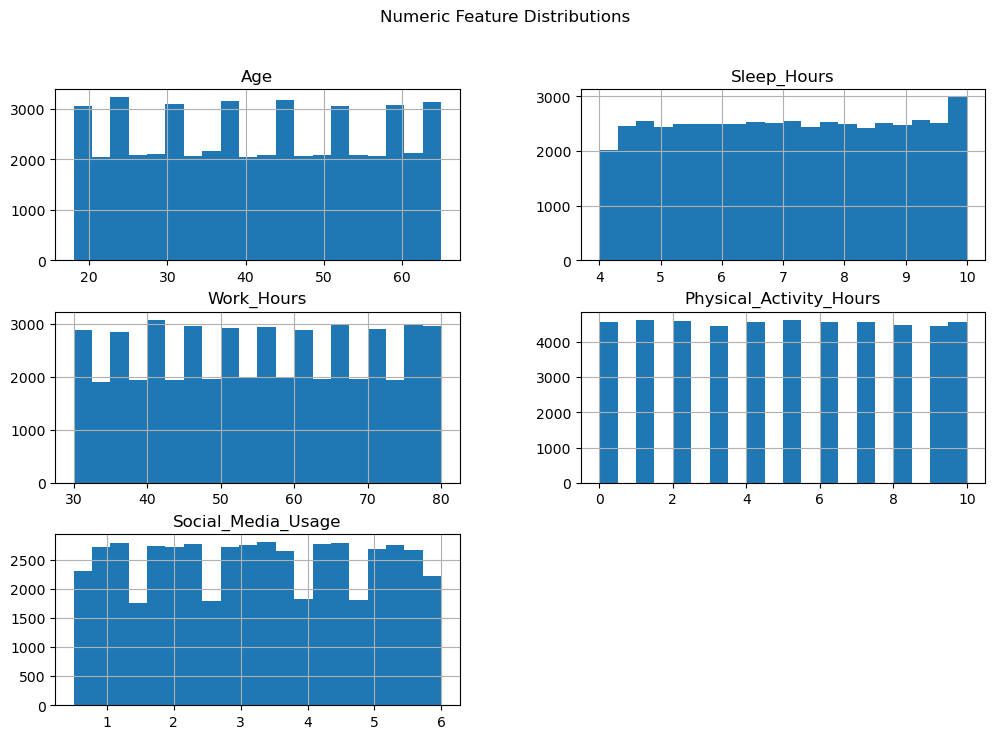

(50000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      50000 non-null  int64  
 1   Gender                   50000 non-null  object 
 2   Mental_Health_Condition  50000 non-null  object 
 3   Severity                 50000 non-null  object 
 4   Stress_Level             50000 non-null  object 
 5   Sleep_Hours              50000 non-null  float64
 6   Work_Hours               50000 non-null  int64  
 7   Physical_Activity_Hours  50000 non-null  int64  
 8   Social_Media_Usage       50000 non-null  float64
 9   Diet_Quality             50000 non-null  object 
 10  Smoking_Habit            50000 non-null  object 
 11  Alcohol_Consumption      50000 non-null  object 
 12  Recovery_Index           50000 non-null  float64
 13  Stress_Proxy             50000 non-null  float64
dtypes: float64

In [134]:
categorical_cols = ['Gender','Diet_Quality','Smoking_Habit','Alcohol_Consumption']

for col in categorical_cols:
    print(f"\n{col} value counts:")
    print(df[col].value_counts(normalize=True).head(10))  # top 10 if many categories

import matplotlib.pyplot as plt

numeric_cols = ['Age','Sleep_Hours','Work_Hours','Physical_Activity_Hours','Social_Media_Usage']

df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Numeric Feature Distributions")
plt.show()


# Basic info
print(df.shape)
print(df.info())
print(df.describe(include='all').T)

# Missing values
print(df.isnull().sum())

# Target distribution
print(df['Stress_Level'].value_counts(normalize=True))


EDA

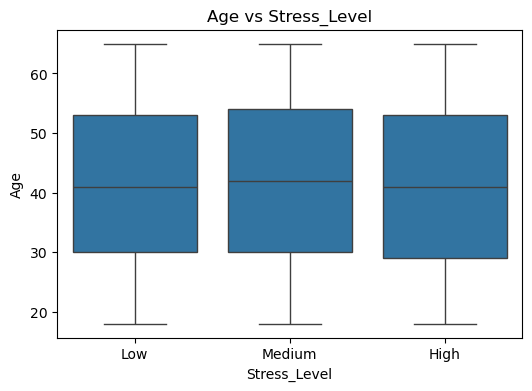

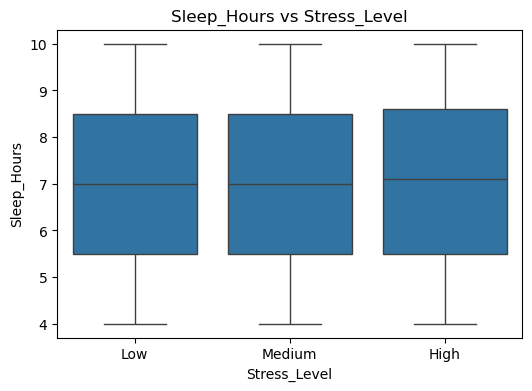

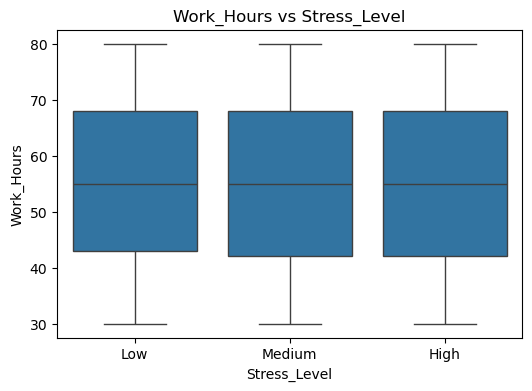

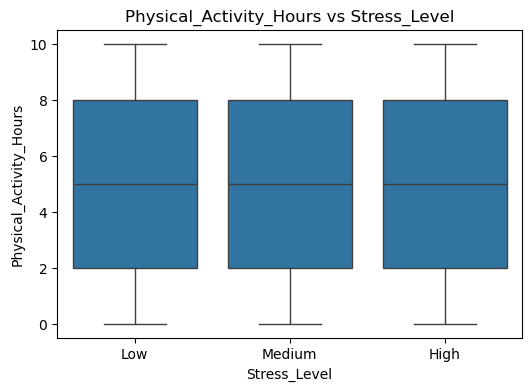

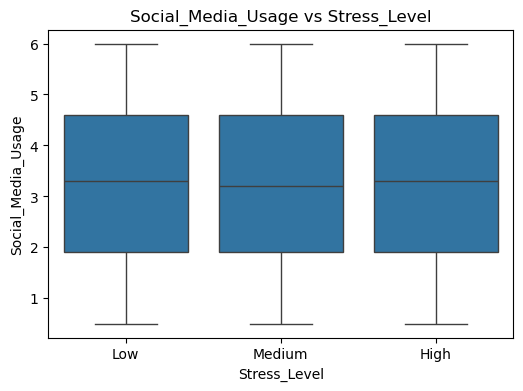

In [135]:
import seaborn as sns

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Stress_Level', y=col, data=df)
    plt.title(f"{col} vs Stress_Level")
    plt.show()


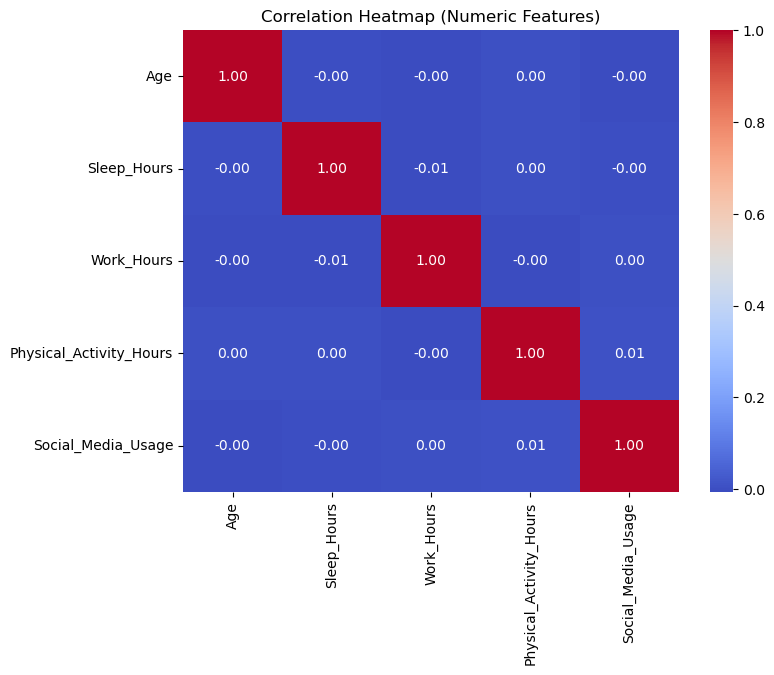

In [136]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()


In [139]:
corr = df[['Age','Sleep_Hours','Work_Hours','Physical_Activity_Hours','Social_Media_Usage']].corr()
print(corr)

#We calculated the correlation matrix of the numeric features (Age, Sleep_Hours, Work_Hours, Physical_Activity_Hours, Social_Media_Usage) to check whether these variables are linearly related to each other.


                              Age  Sleep_Hours  Work_Hours  \
Age                      1.000000    -0.001957   -0.002954   
Sleep_Hours             -0.001957     1.000000   -0.006019   
Work_Hours              -0.002954    -0.006019    1.000000   
Physical_Activity_Hours  0.003151     0.004158   -0.002763   
Social_Media_Usage      -0.004496    -0.001160    0.004516   

                         Physical_Activity_Hours  Social_Media_Usage  
Age                                     0.003151           -0.004496  
Sleep_Hours                             0.004158           -0.001160  
Work_Hours                             -0.002763            0.004516  
Physical_Activity_Hours                 1.000000            0.007439  
Social_Media_Usage                      0.007439            1.000000  


In [138]:
import scipy.stats as stats

for col in ['Age','Sleep_Hours','Work_Hours','Physical_Activity_Hours','Social_Media_Usage']:
    groups = [df[df['Stress_Level']==cls][col].dropna() for cls in df['Stress_Level'].unique()]
    f, p = stats.f_oneway(*groups)
    print(f"{col}: p-value = {p:.4f}")


Age: p-value = 0.3970
Sleep_Hours: p-value = 0.0193
Work_Hours: p-value = 0.2759
Physical_Activity_Hours: p-value = 0.0692
Social_Media_Usage: p-value = 0.2556


Preprocessing

In [113]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)

In [140]:
X = df.drop(columns=['Stress_Level'])
y = (df['Stress_Level'].astype(str).str.strip().str.lower() == 'high').astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Class distribution:\n", y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

Class distribution:
 Stress_Level
0    0.66586
1    0.33414
Name: proportion, dtype: float64


The dataset is not perfectly balanced, but it’s not extremely skewed either

# KNN

In [141]:
# --- 1) Baseline KNN 
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

baseline_pipe = Pipeline(steps=[
    ('preprocess', preprocess),            # senin ColumnTransformer'ın
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance', p=2))  # basit bir başlangıç
])

baseline_pipe.fit(X_train, y_train)
y_pred_base = baseline_pipe.predict(X_test)

print("=== Baseline KNN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_base))
print("\nClassification Report:\n", classification_report(y_test, y_pred_base, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_base))


=== Baseline KNN ===
Accuracy: 0.5952

Classification Report:
               precision    recall  f1-score   support

           0     0.6670    0.7832    0.7204      6659
           1     0.3379    0.2206    0.2669      3341

    accuracy                         0.5952     10000
   macro avg     0.5024    0.5019    0.4937     10000
weighted avg     0.5570    0.5952    0.5689     10000

Confusion Matrix:
 [[5215 1444]
 [2604  737]]


In [116]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('knn', KNeighborsClassifier())
])

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
    'knn__weights': ['uniform', 'distance'],
    'knn__p': [1, 2]  # 1 = Manhattan, 2 = Euclidean
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1_macro',   # fair across classes
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("\n=== Grid Search Results ===")
print("Best params:", grid.best_params_)
print("Best CV f1_macro:", grid.best_score_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\n=== Test Performance (Best KNN) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 24 candidates, totalling 120 fits

=== Grid Search Results ===
Best params: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'uniform'}
Best CV f1_macro: 0.4957705895599567

=== Test Performance (Best KNN) ===
Accuracy: 0.5797

Classification Report:
               precision    recall  f1-score   support

           0     0.6662    0.7393    0.7008      6659
           1     0.3349    0.2616    0.2937      3341

    accuracy                         0.5797     10000
   macro avg     0.5005    0.5004    0.4973     10000
weighted avg     0.5555    0.5797    0.5648     10000

Confusion Matrix:
 [[4923 1736]
 [2467  874]]


# Random Forest

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

rf_pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('rf', RandomForestClassifier(
        n_estimators=200,      # number of trees
        max_depth=None,       # let trees grow deep
        class_weight='balanced', # balance classes (optional)
        random_state=42,
        n_jobs=-1             # use all CPU cores
    ))
])

# --- 5) Train the model
rf_pipe.fit(X_train, y_train)

# --- 6) Predictions
y_pred = rf_pipe.predict(X_test)
y_pred_proba = rf_pipe.predict_proba(X_test)

# --- 7) Evaluation
print("=== Random Forest Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# For AUC (macro average across classes)
try:
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    print("\nMacro AUC:", auc)
except:
    print("\nAUC could not be calculated (needs probabilities).")

=== Random Forest Results ===
Accuracy: 0.6628

Classification Report:
               precision    recall  f1-score   support

           0     0.6656    0.9919    0.7966      6659
           1     0.2987    0.0069    0.0135      3341

    accuracy                         0.6628     10000
   macro avg     0.4822    0.4994    0.4051     10000
weighted avg     0.5430    0.6628    0.5350     10000

Confusion Matrix:
 [[6605   54]
 [3318   23]]

AUC could not be calculated (needs probabilities).


In [122]:
import numpy as np
from sklearn.metrics import roc_auc_score

# Sanity checks
print("Unique classes in y_test:", np.unique(y_test))
print("y_pred_proba shape:", np.array(y_pred_proba).shape)

n_classes = len(np.unique(y_test))

if n_classes == 2:
    # Binary: pozitif sınıfın (genelde 1) olasılığı kullanılmalı -> (n_samples,)
    auc = roc_auc_score(y_test, y_pred_proba[:, 1])
    print("ROC-AUC (binary):", auc)
else:
    # Multiclass: her sınıf için olasılık matrisi -> (n_samples, n_classes)
    auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
    print("ROC-AUC (multiclass, macro OvR):", auc)

Unique classes in y_test: [0 1]
y_pred_proba shape: (10000, 2)
ROC-AUC (binary): 0.49267590084178964


# XGBClassifier

In [118]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [119]:
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',     # fast, scalable
    random_state=42,
    n_estimators=300,       # will be tuned
)

pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('xgb', xgb)
])

In [120]:
# 7) Hyperparameter search (compact but effective grid)
param_grid = {
    'xgb__n_estimators': [200, 400],
    'xgb__max_depth': [4, 6, 8],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__subsample': [0.7, 1.0],
    'xgb__colsample_bytree': [0.7, 1.0],
    'xgb__reg_lambda': [1.0, 5.0]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1_macro',   # fair across classes
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV f1_macro:", grid.best_score_)

best_model = grid.best_estimator_

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/Applications/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 971, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Applications/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 279, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Applications/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_scorer.py", line 376, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                        ^^^^^^^^^^

KeyboardInterrupt: 

In [121]:
# 8) Evaluate
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

print("\n=== XGBoost Test Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Multiclass AUC (OvR macro)
try:
    auc_macro = roc_auc_score(y_test, y_proba, multi_class='ovr')
    print("\nMacro AUC (OvR):", auc_macro)
except Exception as e:
    print("\nAUC could not be computed:", e)


=== XGBoost Test Results ===
Accuracy: 0.5797

Classification Report:
               precision    recall  f1-score   support

           0     0.6662    0.7393    0.7008      6659
           1     0.3349    0.2616    0.2937      3341

    accuracy                         0.5797     10000
   macro avg     0.5005    0.5004    0.4973     10000
weighted avg     0.5555    0.5797    0.5648     10000

Confusion Matrix:
 [[4923 1736]
 [2467  874]]

AUC could not be computed: y should be a 1d array, got an array of shape (10000, 2) instead.


In [124]:
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

# Handle potential imbalance with scale_pos_weight = (neg/pos)
pos = y_train.sum()
neg = len(y_train) - pos
spw = (neg / pos) if pos > 0 else 1.0

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    n_estimators=400,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    scale_pos_weight=spw,   # helps if positive class is rarer
    random_state=42,
    n_jobs=-1
)

pipe = Pipeline(steps=[('preprocess', preprocess),
                      ('xgb', xgb)])

# 7) Fit
pipe.fit(X_train, y_train)

# 8) Evaluate
y_pred = pipe.predict(X_test)
y_proba = pipe.predict_proba(X_test)[:, 1]

print("=== Binary: High vs Not-High (XGBoost) ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Average Precision (PR-AUC):", average_precision_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

=== Binary: High vs Not-High (XGBoost) ===
Accuracy: 0.4775
ROC-AUC: 0.4881052524980201
Average Precision (PR-AUC): 0.32506605119659226

Classification Report:
               precision    recall  f1-score   support

           0     0.6634    0.4372    0.5270      6659
           1     0.3321    0.5579    0.4164      3341

    accuracy                         0.4775     10000
   macro avg     0.4978    0.4975    0.4717     10000
weighted avg     0.5527    0.4775    0.4901     10000

Confusion Matrix:
 [[2911 3748]
 [1477 1864]]


# Naive Bayes

In [126]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Features (drop target)
X = df.drop(columns=['Stress_Level'])
y = (df['Stress_Level'].astype(str).str.strip().str.lower() == 'high').astype(int)


# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Preprocessing: impute + encode
numeric_features = [c for c in X.columns if np.issubdtype(X[c].dtype, np.number)]
categorical_features = [c for c in X.columns if c not in numeric_features]

num_pre = SimpleImputer(strategy='median')
cat_pre = Pipeline(steps=[
    ('imp', SimpleImputer(strategy='most_frequent')),
    ('oh', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', num_pre, numeric_features),
        ('cat', cat_pre, categorical_features)
    ]
)

# Pipeline
nb_pipe = Pipeline(steps=[
    ('preprocess', preprocess),
    ('nb', GaussianNB())
])

# Train
nb_pipe.fit(X_train, y_train)

# Predict
y_pred = nb_pipe.predict(X_test)
y_proba = nb_pipe.predict_proba(X_test)

# Evaluate
print("=== Naive Bayes Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

try:
    auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
    print("ROC-AUC:", auc)
except:
    print("AUC could not be calculated.")


=== Naive Bayes Results ===
Accuracy: 0.6659

Classification Report:
               precision    recall  f1-score   support

           0     0.6659    1.0000    0.7994      6659
           1     0.0000    0.0000    0.0000      3341

    accuracy                         0.6659     10000
   macro avg     0.3330    0.5000    0.3997     10000
weighted avg     0.4434    0.6659    0.5324     10000

Confusion Matrix:
 [[6659    0]
 [3341    0]]
AUC could not be calculated.


/Applications/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Applications/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Logistic Regression + Polynomial Features

In [127]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Features & target (binary example: High vs Not High)
y = (df['Stress_Level'] == 'High').astype(int)
X = df[['Age','Sleep_Hours','Work_Hours','Physical_Activity_Hours','Social_Media_Usage']]  # only numeric for now

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Pipeline with polynomial features
poly_clf = Pipeline(steps=[
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # degree=2 adds squares and interactions
    ('logreg', LogisticRegression(max_iter=500, class_weight='balanced'))
])

# Fit
poly_clf.fit(X_train, y_train)

# Predict
y_pred = poly_clf.predict(X_test)
y_proba = poly_clf.predict_proba(X_test)[:,1]

# Evaluate
print("=== Logistic Regression + Polynomial Features ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))


=== Logistic Regression + Polynomial Features ===
Accuracy: 0.5056
ROC-AUC: 0.5032202177670438

Classification Report:
               precision    recall  f1-score   support

           0     0.6690    0.5098    0.5787      6659
           1     0.3373    0.4972    0.4019      3341

    accuracy                         0.5056     10000
   macro avg     0.5031    0.5035    0.4903     10000
weighted avg     0.5581    0.5056    0.5196     10000



/Applications/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
